In [1]:
import netCDF4 as nc
from pathlib import Path
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib as mpl
import matplotlib.path as mpath
import cartopy.feature as cfeature

import seaborn as sns
import matplotlib.colors as cols
from mpl_toolkits.basemap import Basemap

In [2]:
iceyes = np.load('/media/ub/Elements/iHESPdata/ICE/smalliceallsumtime250-493.npy')
iceyes2 = np.load('/media/ub/Elements/iHESPdata/ICE/smalliceallsumtime495-650.npy')

ice = iceyes/1000000 # m^2 to km^2:q
ice2 = iceyes2/1000000 # m^2 to km^2

timeice=ice/10000000
timeice2=ice2/10000000

timei = np.hstack((timeice, timeice2))

aaa = []
for index, i in enumerate(timei):
    if i >=2:
        aaa.append(index)

bbb = []
for index, i in enumerate(timei):
    if i ==0 :
        bbb.append(index)
        
ccc = []
for index, i in enumerate(timei):
    if 0<i<2 :
        ccc.append(index)

In [4]:
openocean = np.load('/media/ub/Elements/iHESPplot/SWMT/openoceandeep176runing.npy')
openoceantime = np.load('/media/ub/Elements/iHESPplot/SWMT/openoceandeeptime176runing.npy')

DSW1 = np.load('/media/ub/Elements/iHESPplot/iceplot/cross1000sigma1/weDSW1plusplusrun.npy')
DSW1time = np.load('/media/ub/Elements/iHESPplot/iceplot/cross1000sigma1/we2timeplusplusrun.npy')

WSPsmall = np.load('/media/ub/Elements/iHESPplot/iceplot/smallMRP.npy')
WSPbigger = np.load('/media/ub/Elements/iHESPplot/iceplot/smallWSP.npy')

SWMTs = np.load('/media/ub/Elements/iHESPplot/SWMT/SWMTsurface.npy')
SWMTsall = np.load('/media/ub/Elements/iHESPplot/SWMT/SWMTsurfacealltime.npy')

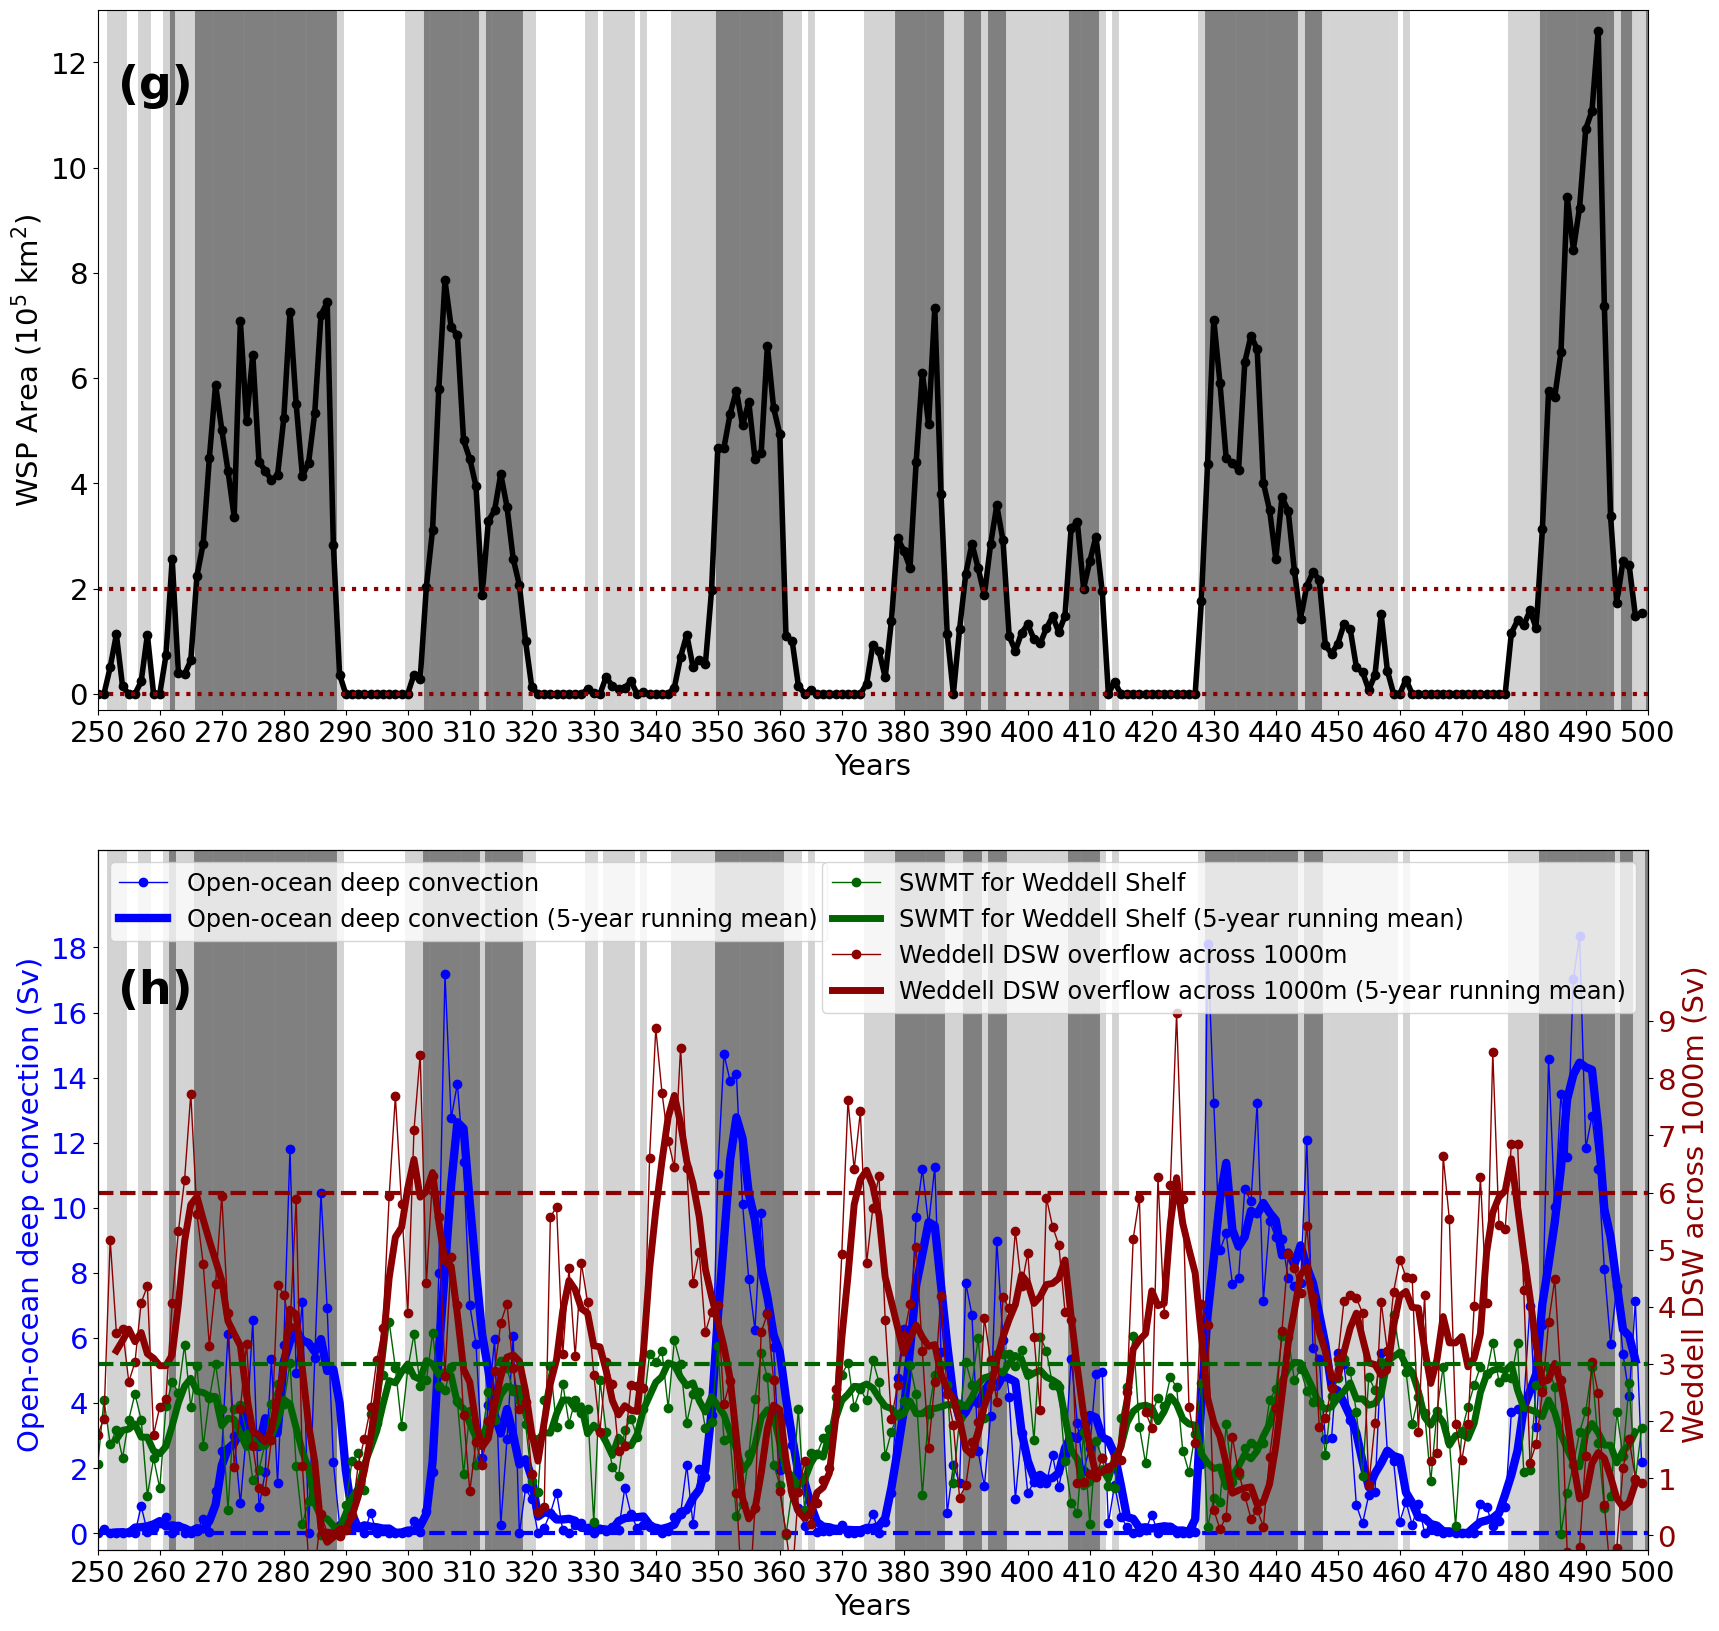

In [25]:
fig = plt.figure(figsize=(20,20), dpi=100)
my_font = {'size':'21'}
################################################################
################################################################
#t = np.arange(0,243,1)
ax1 = plt.subplot(2, 1, 1)
plt.vlines(aaa, -0.3, 13, linestyles="solid", colors="grey" ,linewidth=5)
#plt.vlines(bbb, -0.3, 13, linestyles="solid", colors="red" ,linewidth=5)
plt.vlines(ccc, -0.3, 13, linestyles="solid", colors="lightgrey" ,linewidth=5)


ax1.plot(timei[:250],'k-o',linewidth=4)#,label='Weddell Polynya Area')
#plt.legend(loc='upper center',fontsize='xx-large')
########################################

plt.axis("tight")
plt.yticks(np.arange(0,13,2), ['0','2','4','6','8', '10', '12'],**my_font)
plt.ylabel('WSP Area (10$^5$ km$^2$)',**my_font)

plt.xticks(np.arange(0,260,10), ['250','260','270','280','290','300','310','320','330','340','350','360',\
                                 '370','380','390','400','410','420','430','440','450','460','470','480','490','500'],**my_font)
plt.xlabel('Years',**my_font,color='k')
plt.hlines(0, 0, 400, linestyles="dotted", colors="darkred" ,linewidth=3)
plt.hlines(2, 0, 400, linestyles="dotted", colors="darkred" ,linewidth=3)

ax1.set(ylim=(-0.3, 13),xlim=(0, 250))
ax1.text(3.3, 11.3, '(g)',size=33, weight='bold',color='k')


t = np.arange(3,249,1)
ax2 = plt.subplot(2, 1, 2)

#plt.legend()


plt.vlines(WSPsmall, -1, 24, linestyles="solid", colors="lightgrey" ,linewidth=5)
plt.vlines(WSPbigger, -1, 24, linestyles="solid", colors="grey" ,linewidth=5)
plt.hlines(0,0,250,linestyles="dashed", colors="blue",linewidth=3)
ax2.plot(openoceantime,color='blue',marker='o',linewidth=1,label='Open-ocean deep convection')

ax2.plot(t,openocean,color='blue',linewidth=6,label='Open-ocean deep convection (5-year running mean)')
plt.legend(loc='upper left',fontsize='xx-large')

plt.axis("tight")
plt.yticks(np.arange(0,20,2), ['0','2','4','6','8','10','12','14', '16', '18'],**my_font,color='blue')
plt.ylabel('Open-ocean deep convection (Sv) ',**my_font,color='blue')
#plt.title('Weddell DSW overflow across 1000m isodepth ($\sigma$$_1$>32.58)',**my_font)
plt.xticks(np.arange(0,260,10), ['250','260','270','280','290','300','310','320','330','340','350','360','370','380','390','400','410','420','430','440','450','460','470','480','490','500'],**my_font)
plt.xlabel('Years',**my_font,color='k')
ax2.set(ylim=(-0.5, 21),xlim=(0, 250))


#plt.vlines(49, -1, 20, linestyles="solid", colors="green" ,linewidth=3)

#plt.vlines(93, -1, 20, linestyles="solid", colors="green" ,linewidth=3)
#plt.vlines(124, -1, 20, linestyles="solid", colors="green" ,linewidth=3)
#plt.vlines(177, -1, 20, linestyles="solid", colors="green" ,linewidth=3)
#plt.vlines(228, -1, 20, linestyles="solid", colors="green" ,linewidth=3)

ax2 = ax2.twinx()

ax2.plot(SWMTsall,color='darkgreen',marker='o',linewidth=1,label='SWMT for Weddell Shelf')

ax2.plot(t,SWMTs,color='darkgreen',linewidth=5,label='SWMT for Weddell Shelf (5-year running mean)')

ax2.plot(DSW1time,color='darkred',marker='o',linewidth=1,label='Weddell DSW overflow across 1000m')

ax2.plot(t,DSW1,color='darkred',linewidth=5,label='Weddell DSW overflow across 1000m (5-year running mean)')


ax2.text(3.3, 9.3, '(h)',size=33, weight='bold',color='k')
plt.legend(loc='upper right',fontsize='xx-large')
plt.yticks(np.arange(0,10,1), ['0','1','2','3','4','5','6','7','8','9'],**my_font,color='darkred')
plt.ylabel('Weddell DSW across 1000m (Sv) ',**my_font,color='darkred')
#plt.ylabel('Weddell DSW across  ',**my_font,color='darkred')
plt.hlines(6,0,250,linestyles="dashed", colors="darkred",linewidth=3)
plt.hlines(3, 0, 250, linestyles="dashed", colors="darkgreen" ,linewidth=3)
ax2.set(ylim=(-0.25, 12),xlim=(0, 250))
plt.savefig("Fig1+3.png",bbox_inches='tight')